# Energy: Evaluate Best Checkpoints

Many energy runs timed out before completing the final evaluation step.  
This notebook loads each run's **best checkpoint** (`tr_pred_best.pt`),
reconstructs the prediction model, re-solves decisions with Gurobi,
and computes **val and test regret** from scratch.

Runs found under `saved_records/energy-energy/perturb/sd1_*/`.

In [1]:
import os, sys, glob, time, warnings
import numpy as np
import pandas as pd
import torch

warnings.filterwarnings("ignore")
os.chdir("/cluster/tufts/hugheslab/kheuto01/code/PredictiveCO-Benchmark")
sys.path.insert(0, ".")

from openpto.problems.Energy import Energy
from openpto.method.Solvers.grb.grb_energy import ICONGrbSolver
from openpto.method.Predicts.dense import MLP
from openpto.method.utils_method import to_device

PROJECT_ROOT = os.getcwd()
print(f"Working dir: {PROJECT_ROOT}")
print(f"torch {torch.__version__}, CUDA available: {torch.cuda.is_available()}")

Working dir: /cluster/tufts/hugheslab/kheuto01/code/PredictiveCO-Benchmark
torch 2.6.0+cu124, CUDA available: False


## 1. Load Energy problem + Gurobi solver

This replicates the setup from `main_results.py`.  We only need to do this once
since all energy runs share the same problem instance / data split / solver.

In [2]:
# ── Instantiate problem (deterministic: seed=2023 matches training) ──
problem = Energy(
    prob_version="energy",
    rand_seed=2023,
    data_dir="./openpto/data/energy",
)

# Data splits
X_train, Y_train, Y_train_aux = problem.get_train_data()
X_val,   Y_val,   Y_val_aux   = problem.get_val_data()
X_test,  Y_test,  Y_test_aux  = problem.get_test_data()

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Y shapes: train {Y_train.shape}, val {Y_val.shape}, test {Y_test.shape}")

# ── Solver (Gurobi) ──────────────────────────────────────────────
api_kwargs = problem.init_API()
solver = ICONGrbSolver(**api_kwargs)
print(f"Solver ready: {solver.nbMachines} machines, {solver.nbTasks} tasks")

Train: torch.Size([550, 48, 8]), Val: torch.Size([100, 48, 8]), Test: torch.Size([137, 48, 8])
Y shapes: train torch.Size([550, 48, 1]), val torch.Size([100, 48, 1]), test torch.Size([137, 48, 1])
Restricted license - for non-production use only - expires 2027-11-29
Solver ready: 3 machines, 10 tasks


## 2. Compute optimal decisions (ground truth)

We need $z^*(\theta^*)$ for each partition to compute regret.  
This is the expensive Gurobi solve — takes several minutes.

In [3]:
print("Solving optimal decisions... (this takes a few minutes)")

t0 = time.time()
Z_val_opt, Objs_val_opt = problem.get_decision(
    Y_val, params=Y_val_aux, ptoSolver=solver, isTrain=False, **api_kwargs
)
print(f"  Val  optimal: {time.time()-t0:.1f}s, mean obj = {Objs_val_opt.mean():.2f}")

t0 = time.time()
Z_test_opt, Objs_test_opt = problem.get_decision(
    Y_test, params=Y_test_aux, ptoSolver=solver, isTrain=False, **api_kwargs
)
print(f"  Test optimal: {time.time()-t0:.1f}s, mean obj = {Objs_test_opt.mean():.2f}")

# Store on problem object (needed for regret computation)
problem.z_val_opt  = Z_val_opt
problem.z_test_opt = Z_test_opt

print("\nOptimal decisions cached.")

Solving optimal decisions... (this takes a few minutes)
  Val  optimal: 11.2s, mean obj = 1908243.07
  Test optimal: 17.5s, mean obj = 1913638.76

Optimal decisions cached.


## 3. Model architecture

All energy runs use the same architecture:  
`MLP(num_features, 1, n_layers=2, n_hidden=32, relu, identity)`

In [4]:
# Model shape from problem
ipdim, opdim = problem.get_model_shape()
out_act = problem.get_output_activation()
print(f"Model shape: input={ipdim}, output={opdim}, out_act={out_act}")

def load_model(checkpoint_path):
    """Load a trained prediction model from checkpoint."""
    model = MLP(
        num_features=ipdim,
        num_targets=opdim,
        num_layers=2,
        intermediate_size=32,
        activation="relu",
        output_activation=out_act,
    )
    state_dict = torch.load(checkpoint_path, map_location="cpu", weights_only=True)
    model.load_state_dict(state_dict)
    model.eval()
    return model

# Smoke test
test_ckpt = glob.glob("saved_records/energy-energy/perturb/sd1_*/checkpoints/tr_pred_best.pt")[0]
test_model = load_model(test_ckpt)
print(f"Loaded test model from {test_ckpt}")
print(test_model)

Model shape: input=8, output=1, out_act=identity
Loaded test model from saved_records/energy-energy/perturb/sd1_s005_lr1e2/checkpoints/tr_pred_best.pt
MLP(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 4. Evaluate all checkpoints

For each run:
1. Load best checkpoint
2. Forward pass → predicted coefficients $\hat{\theta}$
3. Solve for decisions $z(\hat{\theta})$ using Gurobi
4. Compute regret = $|f(\theta^*, z(\hat{\theta})) - f(\theta^*, z^*)|$

In [5]:
def evaluate_checkpoint(checkpoint_path, X, Y, Y_aux, Z_opt, partition_name):
    """
    Evaluate a single checkpoint on a given data partition.
    Returns dict with regret stats.
    """
    model = load_model(checkpoint_path)
    
    with torch.no_grad():
        preds = model(X)
    
    # Re-solve with predicted coefficients
    t0 = time.time()
    Z_hat, Objs_hat_pred = problem.get_decision(
        to_device(preds, "cpu"),
        params=Y_aux,
        ptoSolver=solver,
        isTrain=False,
        **api_kwargs,
    )
    solve_time = time.time() - t0
    
    # Compute objectives with TRUE coefficients
    obj_hat  = problem.get_objective(to_device(Y, "cpu"), to_device(Z_hat, "cpu"), Y_aux)
    obj_true = problem.get_objective(to_device(Y, "cpu"), to_device(Z_opt, "cpu"), Y_aux)
    
    # Regret = |obj(true_coeff, predicted_decision) - obj(true_coeff, optimal_decision)|
    regret = torch.abs(obj_hat - obj_true)
    
    # Prediction quality (MSE)
    pred_mse = torch.nn.functional.mse_loss(preds, Y).item()
    
    return {
        "partition": partition_name,
        "mean_regret": regret.mean().item(),
        "std_regret": regret.std().item(),
        "median_regret": regret.median().item(),
        "max_regret": regret.max().item(),
        "mean_obj_hat": obj_hat.mean().item(),
        "mean_obj_opt": obj_true.mean().item(),
        "pred_mse": pred_mse,
        "solve_time": solve_time,
        "n_instances": len(X),
    }

In [6]:
# ── Discover all energy runs ─────────────────────────────────────
run_dirs = sorted(glob.glob("saved_records/energy-energy/perturb/sd1_*/"))
print(f"Found {len(run_dirs)} energy runs\n")

rows = []
for run_dir in run_dirs:
    run_name = os.path.basename(run_dir.rstrip("/"))
    ckpt_path = os.path.join(run_dir, "checkpoints", "tr_pred_best.pt")
    has_results = os.path.exists(os.path.join(run_dir, "results.npy"))
    
    if not os.path.exists(ckpt_path):
        print(f"  SKIP {run_name}: no checkpoint")
        continue
    
    # Parse run config from name:  sd1_s{sigma}_lr{lr}
    parts = run_name.split("_")
    sigma_str = [p for p in parts if p.startswith("s") and p[1:].replace(".","").isdigit()]
    lr_str    = [p for p in parts if p.startswith("lr")]
    
    # Decode sigma
    sigma_map = {"s005": 0.05, "s01": 0.1, "s05": 0.5, "s001": 0.01}
    sigma_val = sigma_map.get(sigma_str[0], float(sigma_str[0][1:])) if sigma_str else None
    
    # Decode lr
    lr_map = {"lr1e2": 0.01, "lr1e3": 0.001, "lr5e3": 0.005}
    lr_val = lr_map.get(lr_str[0], None) if lr_str else None
    
    status = "completed" if has_results else "timed_out"
    print(f"  Evaluating {run_name} (σ={sigma_val}, lr={lr_val}, {status})...")
    
    # Evaluate on val
    val_result = evaluate_checkpoint(
        ckpt_path, X_val, Y_val, Y_val_aux, Z_val_opt, "val"
    )
    val_result.update({"run": run_name, "sigma": sigma_val, "lr": lr_val, "status": status})
    rows.append(val_result)
    
    # Evaluate on test
    test_result = evaluate_checkpoint(
        ckpt_path, X_test, Y_test, Y_test_aux, Z_test_opt, "test"
    )
    test_result.update({"run": run_name, "sigma": sigma_val, "lr": lr_val, "status": status})
    rows.append(test_result)
    
    print(f"    val  regret: {val_result['mean_regret']:.2f}  (solve {val_result['solve_time']:.1f}s)")
    print(f"    test regret: {test_result['mean_regret']:.2f}  (solve {test_result['solve_time']:.1f}s)")

results_df = pd.DataFrame(rows)
print(f"\nDone: {len(rows)} evaluations ({len(rows)//2} runs × 2 partitions)")

Found 9 energy runs

  Evaluating sd1_s005_lr1e2 (σ=0.05, lr=0.01, timed_out)...
    val  regret: 110617.63  (solve 11.6s)
    test regret: 123773.57  (solve 15.1s)
  Evaluating sd1_s005_lr1e3 (σ=0.05, lr=0.001, timed_out)...
    val  regret: 257767.32  (solve 31.6s)
    test regret: 267517.72  (solve 34.0s)
  Evaluating sd1_s005_lr5e3 (σ=0.05, lr=0.005, timed_out)...
    val  regret: 116876.68  (solve 11.2s)
    test regret: 137213.67  (solve 16.6s)
  Evaluating sd1_s01_lr1e2 (σ=0.1, lr=0.01, timed_out)...
    val  regret: 67928.71  (solve 12.3s)
    test regret: 89917.78  (solve 15.4s)
  Evaluating sd1_s01_lr1e3 (σ=0.1, lr=0.001, timed_out)...
    val  regret: 129411.01  (solve 12.5s)
    test regret: 152142.97  (solve 18.4s)
  Evaluating sd1_s01_lr5e3 (σ=0.1, lr=0.005, timed_out)...
    val  regret: 67550.39  (solve 10.2s)
    test regret: 81587.15  (solve 14.8s)
  Evaluating sd1_s05_lr1e2 (σ=0.5, lr=0.01, completed)...
    val  regret: 32349.97  (solve 10.3s)
    test regret: 42940

## 5. Results summary

In [7]:
# ── Val regret pivot table ───────────────────────────────────────
val_df = results_df[results_df["partition"] == "val"].copy()
test_df = results_df[results_df["partition"] == "test"].copy()

print("=" * 70)
print("VALIDATION REGRET")
print("=" * 70)
val_pivot = val_df.pivot(index="sigma", columns="lr", values="mean_regret")
print(val_pivot.to_string(float_format="{:.2f}".format))
print()

print("=" * 70)
print("TEST REGRET")
print("=" * 70)
test_pivot = test_df.pivot(index="sigma", columns="lr", values="mean_regret")
print(test_pivot.to_string(float_format="{:.2f}".format))
print()

# Best configs
print("=" * 70)
print("TOP CONFIGS (by val regret)")
print("=" * 70)
best_val = val_df.sort_values("mean_regret")
for _, r in best_val.iterrows():
    test_row = test_df[test_df["run"] == r["run"]]
    test_reg = test_row["mean_regret"].values[0] if len(test_row) else float("nan")
    marker = " ← BEST" if r.name == best_val.index[0] else ""
    print(f"  σ={r['sigma']:<5} lr={r['lr']:<6} | "
          f"val={r['mean_regret']:>10.2f}  test={test_reg:>10.2f}  "
          f"pred_mse={r['pred_mse']:.4f}  [{r['status']}]{marker}")

VALIDATION REGRET
lr        0.001     0.005     0.010
sigma                              
0.05  257767.32 116876.68 110617.63
0.10  129411.01  67550.39  67928.71
0.50   91184.39  45359.62  32349.97

TEST REGRET
lr        0.001     0.005     0.010
sigma                              
0.05  267517.72 137213.67 123773.57
0.10  152142.97  81587.15  89917.78
0.50  116327.43  54859.25  42940.25

TOP CONFIGS (by val regret)
  σ=0.5   lr=0.01   | val=  32349.97  test=  42940.25  pred_mse=5264.4604  [completed] ← BEST
  σ=0.5   lr=0.005  | val=  45359.62  test=  54859.25  pred_mse=5248.1436  [completed]
  σ=0.1   lr=0.005  | val=  67550.39  test=  81587.15  pred_mse=5261.3965  [timed_out]
  σ=0.1   lr=0.01   | val=  67928.71  test=  89917.78  pred_mse=5252.5420  [timed_out]
  σ=0.5   lr=0.001  | val=  91184.39  test= 116327.43  pred_mse=5239.3218  [timed_out]
  σ=0.05  lr=0.01   | val= 110617.63  test= 123773.57  pred_mse=5297.1191  [timed_out]
  σ=0.05  lr=0.005  | val= 116876.68  test= 137213.

In [8]:
# ── Detailed results table ───────────────────────────────────────
display_cols = ["run", "partition", "sigma", "lr", "status",
               "mean_regret", "std_regret", "median_regret", "max_regret",
               "mean_obj_hat", "mean_obj_opt", "pred_mse", "solve_time"]
print(results_df[display_cols].to_string(index=False, float_format="{:.2f}".format))

           run partition  sigma   lr    status  mean_regret  std_regret  median_regret  max_regret  mean_obj_hat  mean_obj_opt  pred_mse  solve_time
sd1_s005_lr1e2       val   0.05 0.01 timed_out    110617.63   151865.19       57950.42   709689.96    2018860.70    1908243.07   5297.12       11.61
sd1_s005_lr1e2      test   0.05 0.01 timed_out    123773.57   142604.19       56482.52   680050.54    2037412.33    1913638.76   5325.39       15.11
sd1_s005_lr1e3       val   0.05 0.00 timed_out    257767.32   205200.04      219624.84   944057.73    2166010.39    1908243.07   5241.86       31.56
sd1_s005_lr1e3      test   0.05 0.00 timed_out    267517.72   185822.65      227934.85   790326.76    2181156.48    1913638.76   5278.79       33.96
sd1_s005_lr5e3       val   0.05 0.01 timed_out    116876.68   171237.94       46170.79   886056.59    2025119.75    1908243.07   5251.88       11.21
sd1_s005_lr5e3      test   0.05 0.01 timed_out    137213.67   160440.39       67380.64   808635.95    2050

## 6. Compare with completed runs' original results

For runs that did complete, compare our re-evaluation with the saved `results.npy`
to validate consistency.

In [9]:
print("Validation: comparing re-evaluated vs original results.npy\n")

for run_dir in run_dirs:
    run_name = os.path.basename(run_dir.rstrip("/"))
    results_path = os.path.join(run_dir, "results.npy")
    if not os.path.exists(results_path):
        continue
    
    saved = np.load(results_path, allow_pickle=True)
    saved_test_obj_opt = saved[0]  # Objs_test_opt
    saved_test_regret  = saved[1]  # eval_value (per-instance test regret)
    
    # Compare with our re-evaluation
    our = test_df[test_df["run"] == run_name]
    if len(our) == 0:
        continue
    
    our_mean = our["mean_regret"].values[0]
    saved_mean = np.mean(saved_test_regret)
    
    match = "✓" if abs(our_mean - saved_mean) < 1.0 else "✗ MISMATCH"
    print(f"  {run_name}: saved={saved_mean:.2f}, ours={our_mean:.2f}  {match}")

Validation: comparing re-evaluated vs original results.npy

  sd1_s05_lr1e2: saved=42940.25, ours=42940.25  ✓
  sd1_s05_lr5e3: saved=54859.35, ours=54859.25  ✓


## 7. Visualization

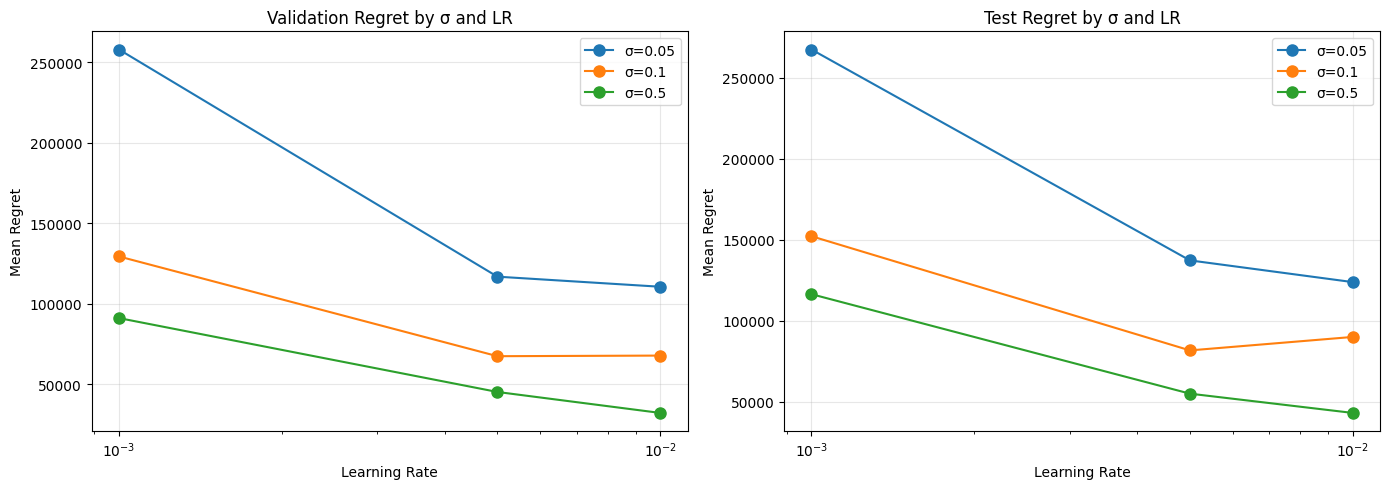

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, partition, df in [(axes[0], "Validation", val_df), (axes[1], "Test", test_df)]:
    for sigma_val in sorted(df["sigma"].unique()):
        sub = df[df["sigma"] == sigma_val].sort_values("lr")
        ax.plot(sub["lr"], sub["mean_regret"], "o-", label=f"σ={sigma_val}", markersize=8)
    ax.set_xlabel("Learning Rate")
    ax.set_ylabel("Mean Regret")
    ax.set_title(f"{partition} Regret by σ and LR")
    ax.set_xscale("log")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

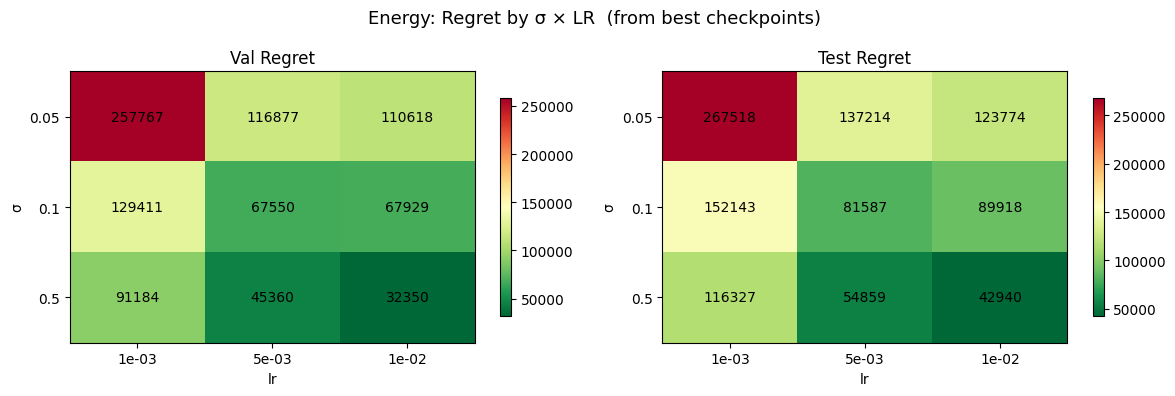

In [11]:
# ── Heatmap: σ vs lr ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, partition, title in [(axes[0], "val", "Val Regret"),
                              (axes[1], "test", "Test Regret")]:
    pdf = results_df[results_df["partition"] == partition]
    pivot = pdf.pivot(index="sigma", columns="lr", values="mean_regret")
    
    im = ax.imshow(pivot.values, cmap="RdYlGn_r", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"{v:.0e}" for v in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([str(v) for v in pivot.index])
    ax.set_xlabel("lr")
    ax.set_ylabel("σ")
    ax.set_title(title)
    
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            v = pivot.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=10)
    fig.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle("Energy: Regret by σ × LR  (from best checkpoints)", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Save results to CSV

In [12]:
out_path = "saved_records/energy-energy/checkpoint_eval_results.csv"
results_df.to_csv(out_path, index=False)
print(f"Saved to {out_path}")
print(f"\nBest val regret:  {val_df['mean_regret'].min():.2f}")
print(f"Best test regret: {test_df['mean_regret'].min():.2f}")
best_run = val_df.loc[val_df['mean_regret'].idxmin(), 'run']
print(f"Best config (by val): {best_run}")

Saved to saved_records/energy-energy/checkpoint_eval_results.csv

Best val regret:  32349.97
Best test regret: 42940.25
Best config (by val): sd1_s05_lr1e2
